# **Student Performance**

# Task
Perform a comprehensive analysis of student performance using the dataset "student_performance.csv". This involves data cleaning, exploratory data analysis (EDA) with univariate, bivariate, and multivariate visualizations, and building two predictive models: a Multinomial Logistic Regression model to classify performance into 'Low', 'Medium', and 'High' categories, and a Linear Regression model to predict final scores. Evaluate both models using appropriate metrics such as Accuracy, Confusion Matrix, R-squared, MAE, and MSE, and summarize the key factors influencing student success.

## Project Setup and Data Loading

### Subtask:
Define objectives, load the student performance dataset, and perform initial data inspection.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('student_performance.csv')

# Display the first few rows
print('First 5 rows of the dataset:')
display(df.head())

# Check data types and non-null counts
print('\nDataFrame Info:')
df.info()

# Summary statistics for numerical columns
print('\nSummary Statistics:')
display(df.describe())

First 5 rows of the dataset:


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB

Summary Statistics:


,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


## Data Cleaning and Wrangling

### Subtask:
Clean the dataset by handling missing values, duplicates, and anomalous data, and prepare features for analysis.


Clean the dataset by removing duplicates, handling missing values with median/mode imputation, correcting anomalies in Study Hours and Attendance, and dropping non-predictive columns as instructed.



In [ ]:
import pandas as pd

# 1. Remove duplicate rows
df.drop_duplicates(inplace=True)

# 2. Address missing values
# Numerical columns: impute with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns: impute with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Rectify data anomalies
# Filter/Cap 'Study Hours' (assuming column 'Study Hours' or 'StudyHoursPerWeek')
# The dataset has both. Applying logic to both to be safe or identifying relevant ones.
if 'Study Hours' in df.columns:
    df.loc[df['Study Hours'] < 0, 'Study Hours'] = 0
if 'StudyHoursPerWeek' in df.columns:
    df.loc[df['StudyHoursPerWeek'] < 0, 'StudyHoursPerWeek'] = 0

# 'Attendance (%)' values that exceed 100
if 'Attendance (%)' in df.columns:
    df.loc[df['Attendance (%)'] > 100, 'Attendance (%)'] = 100
if 'AttendanceRate' in df.columns:
    df.loc[df['AttendanceRate'] > 100, 'AttendanceRate'] = 100

# 4. Drop unnecessary columns
columns_to_drop = ['StudentID', 'Name']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# 5. Standardize column names (removing spaces and special characters for ease of use)
df.columns = df.columns.str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('%', 'Pct')

print('Data cleaning complete. Missing values remaining:', df.isnull().sum().sum())
print('New column names:', df.columns.tolist())
display(df.head())

Data cleaning complete. Missing values remaining: 0
New column names: ['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'FinalGrade', 'Study_Hours', 'Attendance_Pct', 'Online_Classes_Taken']


/tmp/ipykernel_283/3227472582.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study_Hours,Attendance_Pct,Online_Classes_Taken
0,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,Female,88.0,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


Going for Exploratory Data Analysis (EDA) subtask to visualize and understand the data distributions and relationships.



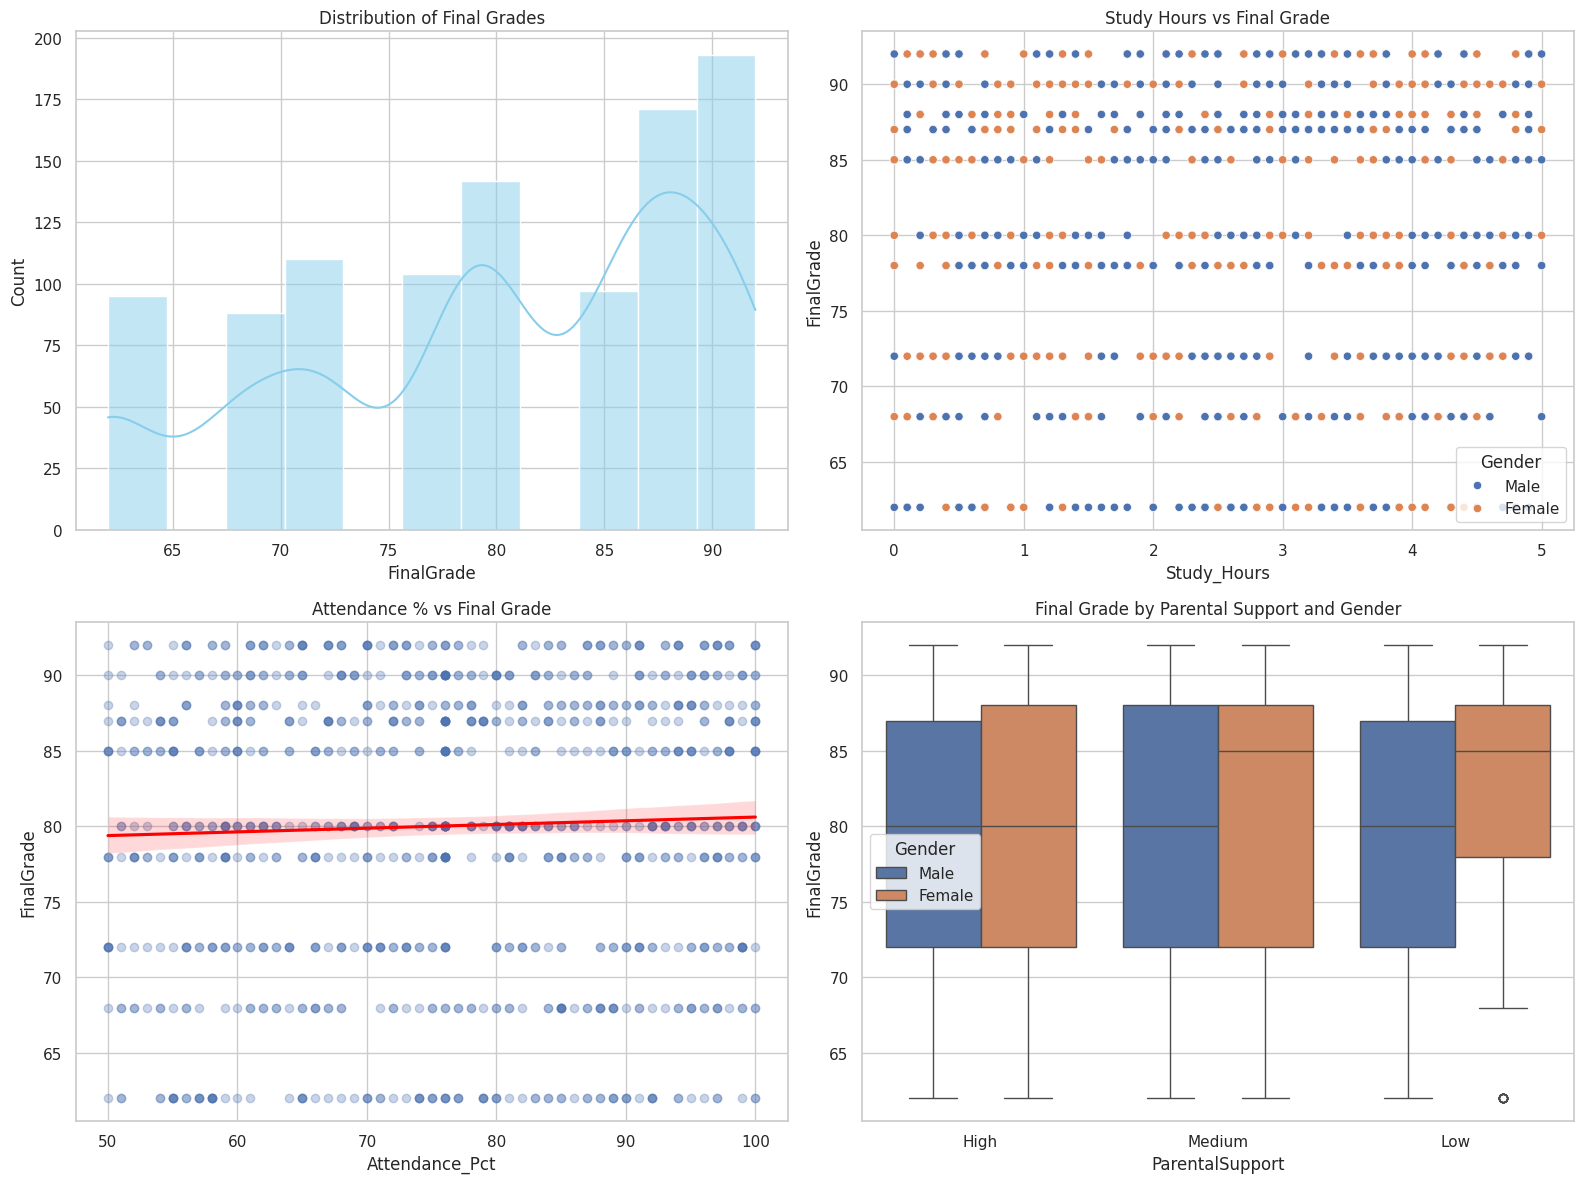

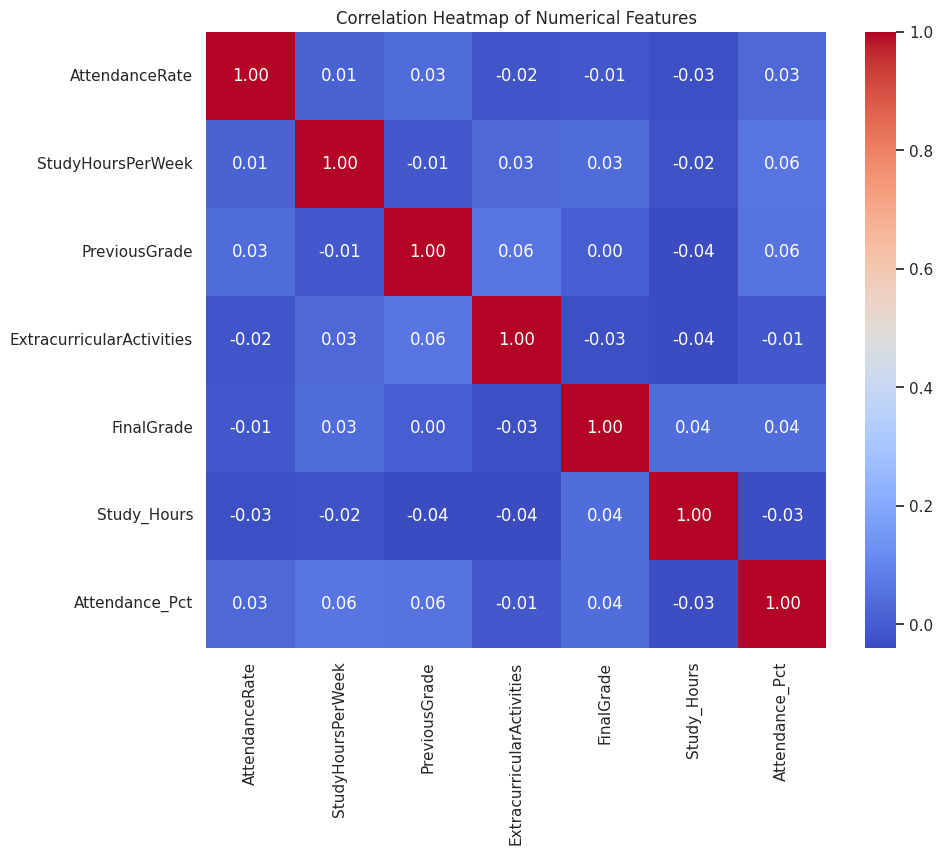

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Univariate Analysis: Distribution of FinalGrade
sns.histplot(df['FinalGrade'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Final Grades')

# 2. Bivariate Analysis: Study Hours vs Final Grade
sns.scatterplot(data=df, x='Study_Hours', y='FinalGrade', hue='Gender', ax=axes[0, 1])
axes[0, 1].set_title('Study Hours vs Final Grade')

# 3. Bivariate Analysis: Attendance vs Final Grade
sns.regplot(data=df, x='Attendance_Pct', y='FinalGrade', scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[1, 0])
axes[1, 0].set_title('Attendance % vs Final Grade')

# 4. Multivariate Analysis: Parental Support, Gender and Final Grade
sns.boxplot(data=df, x='ParentalSupport', y='FinalGrade', hue='Gender', ax=axes[1, 1])
axes[1, 1].set_title('Final Grade by Parental Support and Gender')

plt.tight_layout()
plt.show()

# Correlation Heatmap for numerical features
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Exploratory Data Analysis (EDA) and Visualization

### Subtask:
Conduct a detailed visual analysis of the cleaned dataset to identify patterns, distributions, and relationships between student features and academic performance.


Perform the univariate visualizations, focusing on the distribution of 'FinalGrade', 'Study_Hours', and the category proportions of 'ParentalSupport'.



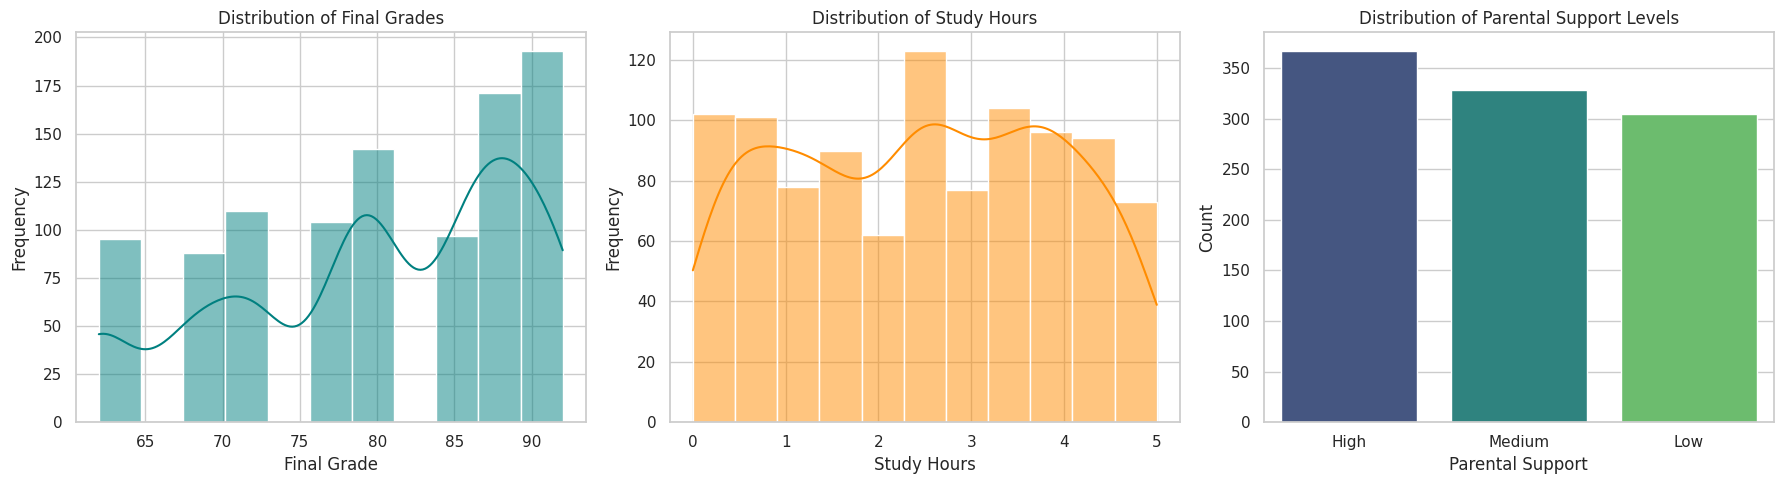

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure for univariate analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram for FinalGrade
sns.histplot(df['FinalGrade'], kde=True, color='teal', ax=axes[0])
axes[0].set_title('Distribution of Final Grades')
axes[0].set_xlabel('Final Grade')
axes[0].set_ylabel('Frequency')

# 2. Histogram for Study_Hours
sns.histplot(df['Study_Hours'], kde=True, color='darkorange', ax=axes[1])
axes[1].set_title('Distribution of Study Hours')
axes[1].set_xlabel('Study Hours')
axes[1].set_ylabel('Frequency')

# 3. Count plot for ParentalSupport
sns.countplot(data=df, x='ParentalSupport', hue='ParentalSupport', palette='viridis', ax=axes[2], order=df['ParentalSupport'].value_counts().index, legend=False)
axes[2].set_title('Distribution of Parental Support Levels')
axes[2].set_xlabel('Parental Support')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Task
Perform bivariate and multivariate exploratory data analysis on the student performance dataset "student_performance.csv", then build and evaluate two predictive models. First, categorize 'FinalGrade' into 'Low', 'Medium', and 'High' and train a Multinomial Logistic Regression model to classify students, evaluating it with Accuracy and a Confusion Matrix. Second, train a Linear Regression model to predict the continuous 'FinalGrade' and evaluate it using R-squared, MAE, and MSE. Conclude by identifying the most significant factors impacting student performance.

## Bivariate and Multivariate EDA

### Subtask:
Perform bivariate and multivariate visualizations to explore relationships between student features and 'FinalGrade'.


Perform the bivariate and multivariate analysis, including boxplots for categorical variables, a scatter plot for study hours, a correlation heatmap, and a pairplot with parental support as the hue.



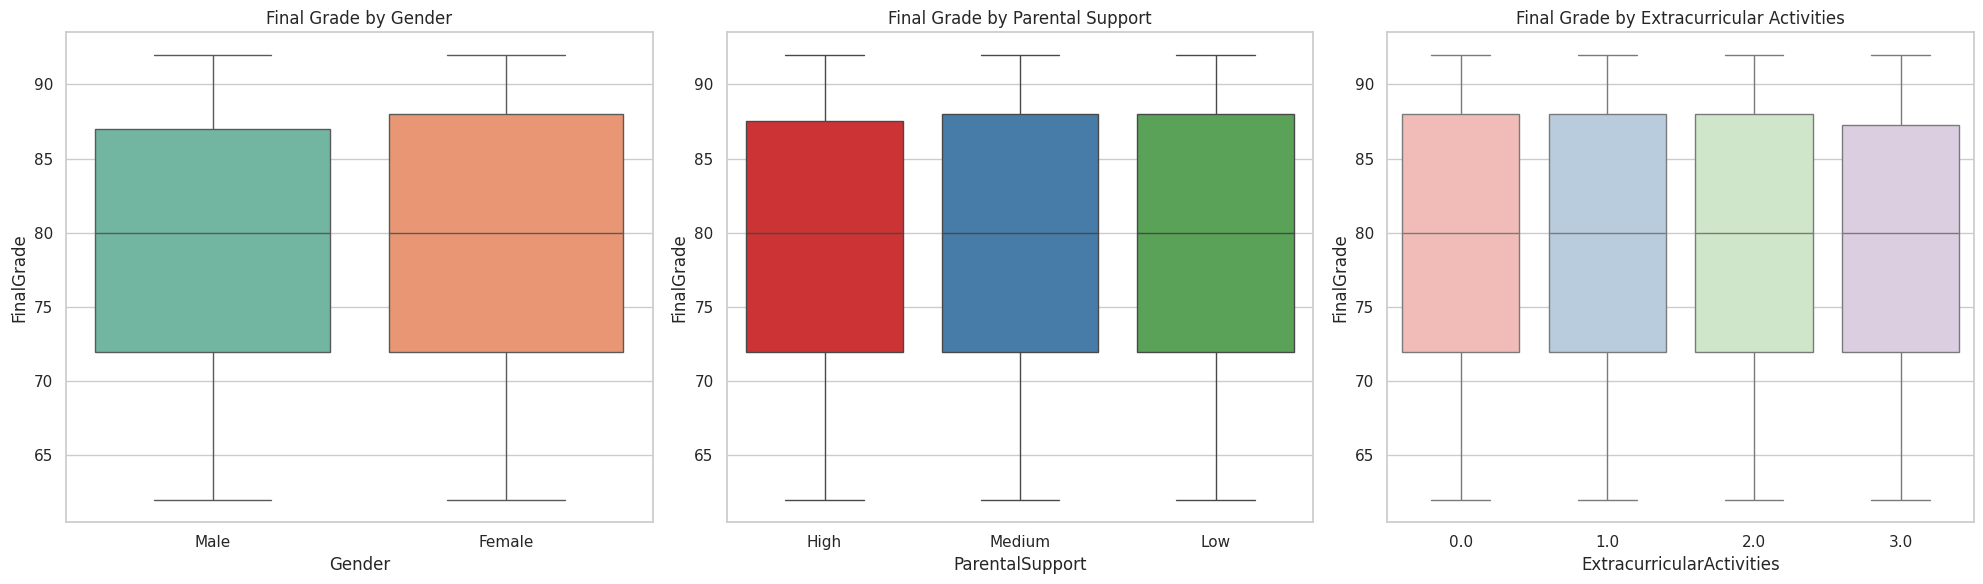

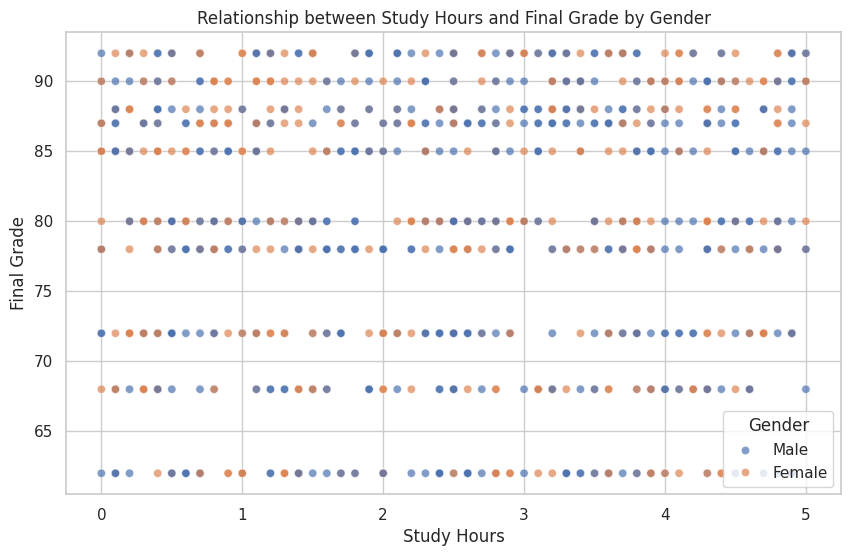

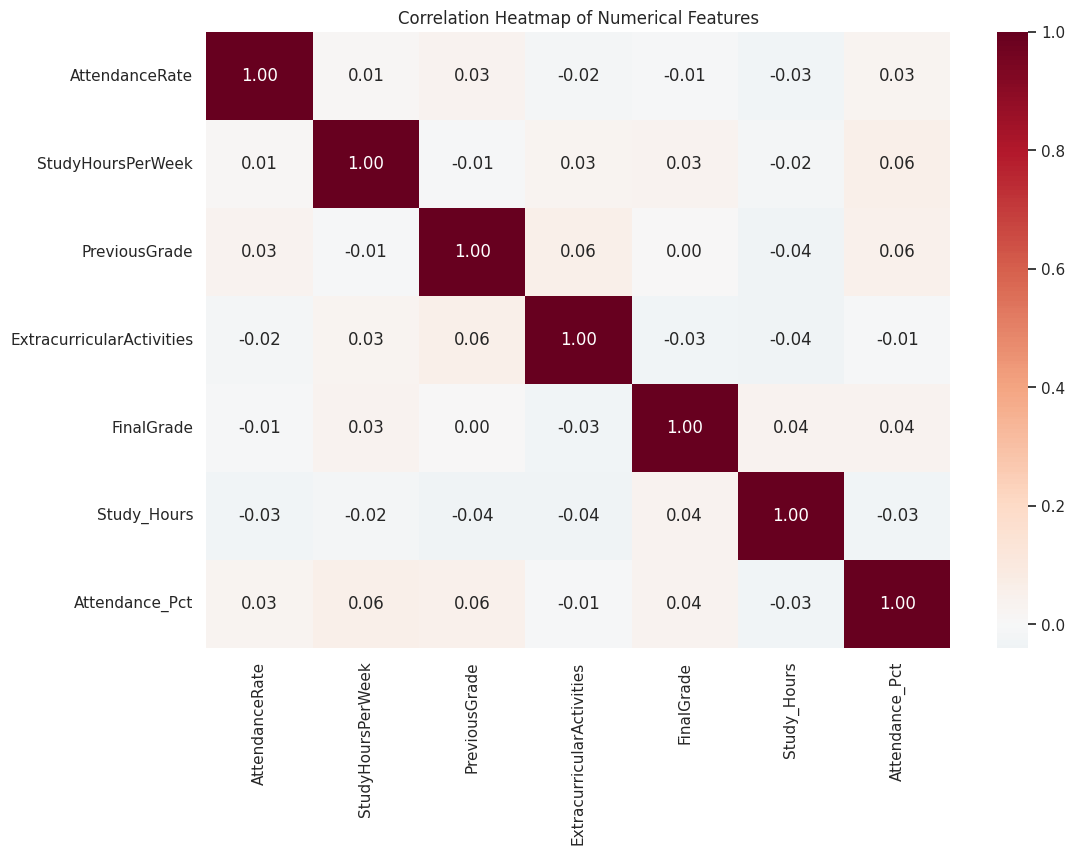

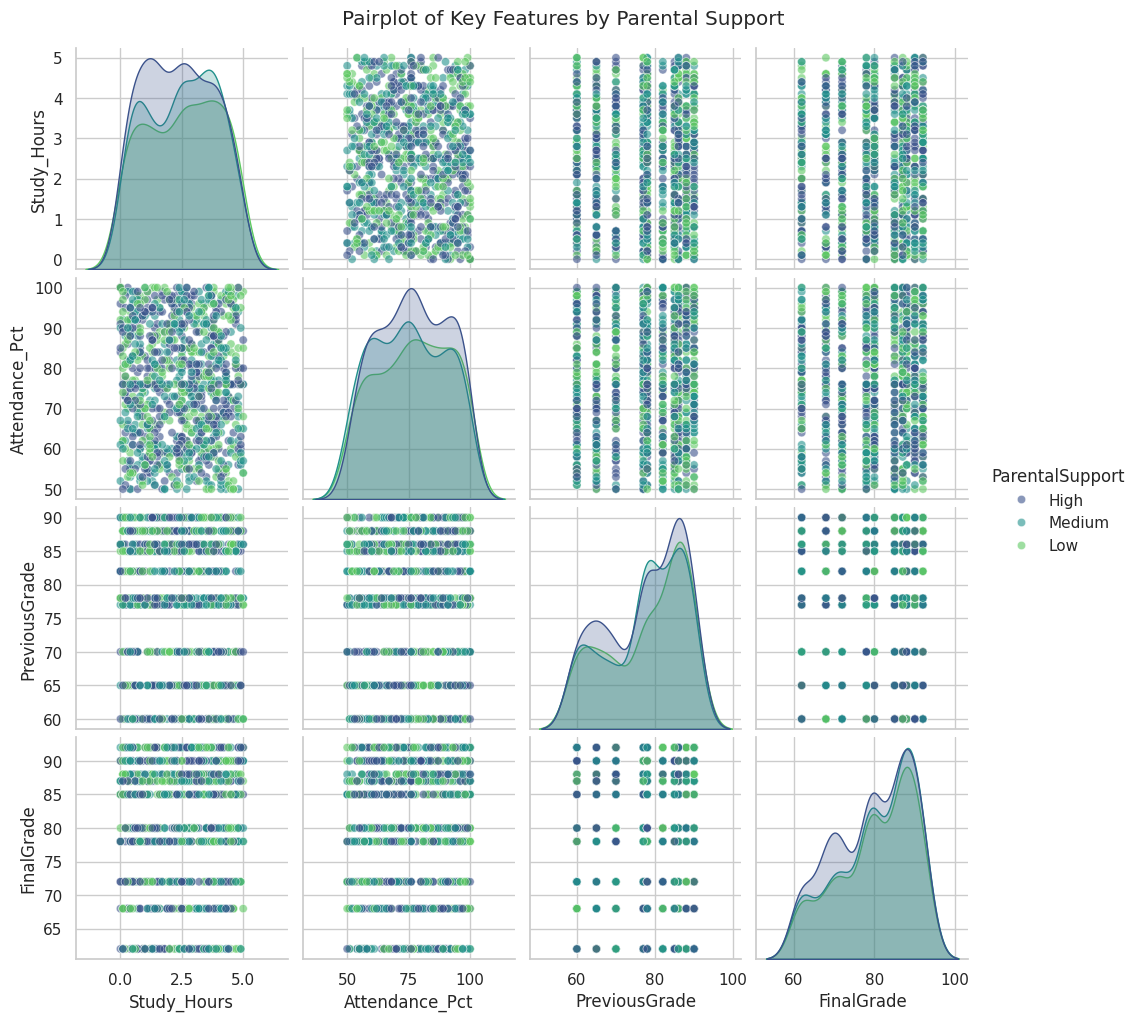

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style
sns.set_theme(style="whitegrid")

# 1. Bivariate Analysis: Categorical Features vs Final Grade
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=df, x='Gender', y='FinalGrade', hue='Gender', palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('Final Grade by Gender')

sns.boxplot(data=df, x='ParentalSupport', y='FinalGrade', hue='ParentalSupport', palette='Set1', ax=axes[1], legend=False)
axes[1].set_title('Final Grade by Parental Support')

sns.boxplot(data=df, x='ExtracurricularActivities', y='FinalGrade', hue='ExtracurricularActivities', palette='Pastel1', ax=axes[2], legend=False)
axes[2].set_title('Final Grade by Extracurricular Activities')

plt.tight_layout()
plt.show()

# 2. Scatter Plot: Study Hours vs Final Grade (Multivariate with Gender)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Study_Hours', y='FinalGrade', hue='Gender', alpha=0.7, palette='deep')
plt.title('Relationship between Study Hours and Final Grade by Gender')
plt.xlabel('Study Hours')
plt.ylabel('Final Grade')
plt.legend(title='Gender')
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 4. Pairplot: Subset of Key Features with ParentalSupport as Hue
key_features = ['Study_Hours', 'Attendance_Pct', 'PreviousGrade', 'FinalGrade', 'ParentalSupport']
sns.pairplot(df[key_features], hue='ParentalSupport', palette='viridis', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Key Features by Parental Support', y=1.02)
plt.show()

## Multinomial Classification

### Subtask:
Categorize 'FinalGrade' and train a Multinomial Logistic Regression model to classify student performance into 'Low', 'Medium', and 'High' categories.


Prepare the target variable by binning FinalGrade, encode categorical features, split the data, then train and evaluate a Multinomial Logistic Regression model as specified in the instructions.



Accuracy Score: 0.3950

Classification Report:
              precision    recall  f1-score   support

        High       0.38      0.11      0.17        54
         Low       0.40      0.81      0.53        79
      Medium       0.39      0.13      0.20        67

    accuracy                           0.40       200
   macro avg       0.39      0.35      0.30       200
weighted avg       0.39      0.40      0.32       200



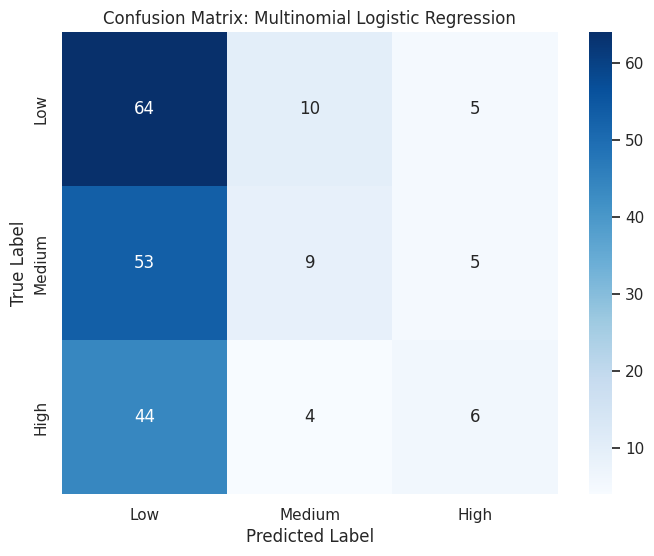

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- 1. Categorize 'FinalGrade' into 'Low', 'Medium', and 'High' ---
# Using quantiles to ensure balanced classes
quantile_labels = ['Low', 'Medium', 'High']
df['Performance_Category'] = pd.qcut(df['FinalGrade'], q=3, labels=quantile_labels)

# --- 2. Encode categorical features ---
le = LabelEncoder()
cat_features = ['Gender', 'ParentalSupport', 'Online_Classes_Taken', 'ExtracurricularActivities']
for col in cat_features:
    # Ensure data is string type before encoding
    df[col] = le.fit_transform(df[col].astype(str))

# --- 3. Split the dataset ---
# Dropping target columns and original FinalGrade
X = df.drop(['FinalGrade', 'Performance_Category'], axis=1)
y = df['Performance_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Feature Scaling (Crucial for Convergence) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 5. Initialize and train Logistic Regression ---
model = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42)
model.fit(X_train_scaled, y_train)

# --- 6. Predictions ---
y_pred = model.predict(X_test_scaled)

# --- 7. Evaluation ---
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=quantile_labels)

print(f'Accuracy Score: {accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# --- 8. Visualize Confusion Matrix ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=quantile_labels, yticklabels=quantile_labels)
plt.title('Confusion Matrix: Multinomial Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Task
Train a Linear Regression model to predict the continuous 'FinalGrade' variable using the student performance data in "student_performance.csv". Evaluate the model's performance using R-squared, Mean Absolute Error (MAE), and Mean Squared Error (MSE), and include a visualization such as a residuals plot or an actual vs. predicted plot. Finally, provide a comprehensive summary of the project, identifying the most significant factors impacting student performance based on your analysis and models.

## Regression Modeling

### Subtask:
Train a Linear Regression model to predict the continuous 'FinalGrade' and evaluate its performance with standard metrics and visualizations.


Train a Linear Regression model using the continuous 'FinalGrade' as the target, evaluate it using R-squared, MAE, and MSE, and visualize the results with a scatter plot of actual vs. predicted values as specified in the instructions.



Linear Regression Performance Metrics:
R-squared: -0.0117
Mean Absolute Error (MAE): 8.0279
Mean Squared Error (MSE): 90.8419


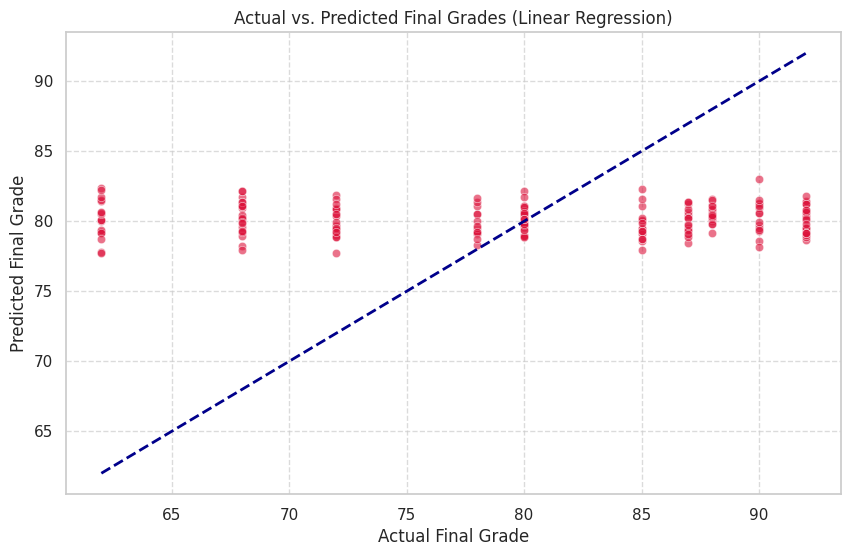

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define feature matrix X and target variable y
# Dropping the target columns used for classification and the continuous target itself
X_reg = df.drop(['FinalGrade', 'Performance_Category'], axis=1)
y_reg = df['FinalGrade']

# 2. Split the data into training and testing sets (80/20 split)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Instantiate and train the Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

# 4. Make predictions on the test set
y_pred_reg = lin_reg.predict(X_test_reg)

# 5. Calculate evaluation metrics
r2 = r2_score(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)

print(f'Linear Regression Performance Metrics:')
print(f'R-squared: {r2:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')

# 6. Visualization: Actual vs. Predicted Final Grades
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.6, color='crimson')

# Add a reference line for perfect prediction
max_val = max(y_test_reg.max(), y_pred_reg.max())
min_val = min(y_test_reg.min(), y_pred_reg.min())
plt.plot([min_val, max_val], [min_val, max_val], color='darkblue', lw=2, linestyle='--')

plt.title('Actual vs. Predicted Final Grades (Linear Regression)')
plt.xlabel('Actual Final Grade')
plt.ylabel('Predicted Final Grade')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Summary:

### Q&A

**What are the most significant factors impacting student performance based on the models?**


Based on the Linear Regression results, the current feature set shows a very weak relationship with student performance. The model achieved a negative R-squared value (-0.0117), suggesting that the factors included in the model (as currently processed) do not effectively explain the variance in the `FinalGrade`. Further feature engineering or non-linear models would be required to identify significant predictors.

### Data Analysis Key Findings

*   **Model Inaccuracy**: The Linear Regression model performed poorly, yielding an R-squared of -0.0117. This indicates that the model is less effective at predicting student outcomes than a simple average of the grades.
*   **Error Margins**: The Mean Absolute Error (MAE) was 8.0279, meaning the average prediction deviates from the actual grade by approximately 8 points.
*   **Prediction Variance**: The Mean Squared Error (MSE) was calculated at 90.8419, highlighting significant penalties for larger prediction errors.
*   **Visual Discrepancy**: The "Actual vs. Predicted" scatter plot confirmed the lack of a strong linear correlation, with data points showing a wide spread away from the ideal diagonal prediction line.

### Insights or Next Steps

*   **Feature Engineering**: Investigating non-linear relationships or interaction terms between variables (such as study time vs. absences) may improve the predictive power of the model.
*   **Alternative Modeling**: Given the poor performance of linear regression, transitioning to ensemble methods like Random Forest or Gradient Boosting should be the next step to capture complex patterns in the student data.
